# House Prices — Advanced Regression Techniques

Single-notebook pipeline for the Kaggle competition.

**Goal:** predict `SalePrice` for each house in `test.csv`.
**Metric:** RMSE on `log(SalePrice)` — we train & predict in log space.
**Submission:** CSV with `Id,SalePrice` (real dollars), matching `sample_submission.csv`.

See `ROADMAP.md` for the full plan.

## Phase 0 — Setup

In [ ]:
# Core imports
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Gradient-boosting libs: preinstalled on Kaggle, `pip install xgboost lightgbm` locally. Optional.
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
sns.set_style("whitegrid")
%matplotlib inline
print("xgboost available:", HAS_XGB, "| lightgbm available:", HAS_LGBM)

In [ ]:
# Reproducibility
SEED = 42
np.random.seed(SEED)

In [ ]:
# Data location — works both locally and on Kaggle.
# Local data lives in ./dataset; Kaggle mounts it under /kaggle/input/...
KAGGLE_DIR = "/kaggle/input/house-prices-advanced-regression-techniques"
DATA_DIR = KAGGLE_DIR if os.path.exists(KAGGLE_DIR) else "dataset"

train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_submission = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

print("train:", train.shape)
print("test: ", test.shape)
print("sample_submission:", sample_submission.shape)

train: (1460, 81)
test:  (1459, 80)
sample_submission: (1459, 2)


## Phase 1 — Explore the data (EDA)

Goal of this phase is to *understand*, not change, the data:
- shape & column types
- the target `SalePrice` (and why we log it)
- which columns are missing and how much
- what drives price (correlations)
- obvious outliers to deal with in Phase 2

### 1.1 First look

In [ ]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Column types: how many numeric vs categorical?
num_cols = train.select_dtypes(include=[np.number]).columns.drop(["Id", "SalePrice"])
cat_cols = train.select_dtypes(include=["object"]).columns
print(f"numeric features:     {len(num_cols)}")
print(f"categorical features: {len(cat_cols)}")

numeric features:     36
categorical features: 43


### 1.2 The target: `SalePrice`
It's strongly right-skewed (a few very expensive houses). The competition metric is RMSE on `log(SalePrice)`, and a `log1p` transform makes the target nearly normal — both reasons to model in log space.

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

skew (raw):  1.883
skew (log1p): 0.121


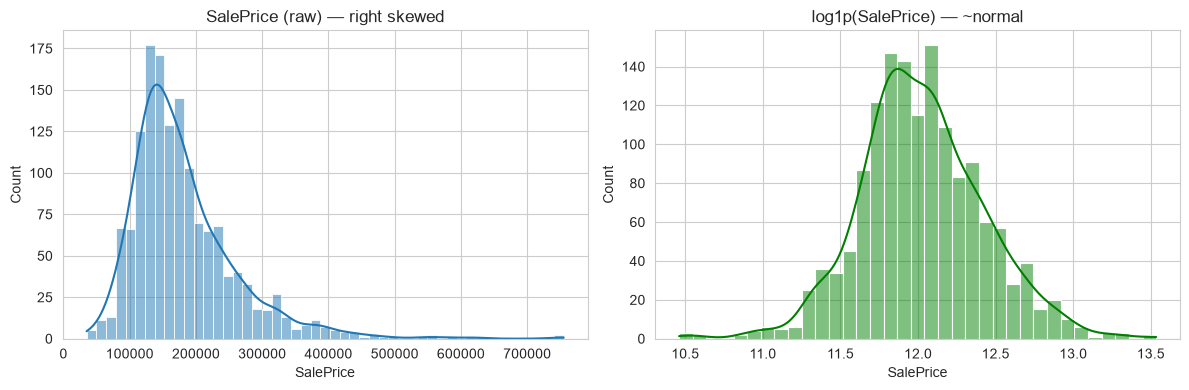

In [ ]:
print(train["SalePrice"].describe())
print(f"\nskew (raw):  {train['SalePrice'].skew():.3f}")
print(f"skew (log1p): {np.log1p(train['SalePrice']).skew():.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train["SalePrice"], kde=True, ax=ax[0])
ax[0].set_title("SalePrice (raw) — right skewed")
sns.histplot(np.log1p(train["SalePrice"]), kde=True, ax=ax[1], color="green")
ax[1].set_title("log1p(SalePrice) — ~normal")
plt.tight_layout()
plt.show()

### 1.3 Missing values
Checked across train + test together so we treat both consistently. Many of these blanks are **not** truly missing — e.g. a blank `PoolQC`/`Alley`/`GarageType` means the house simply has no pool/alley/garage. We'll encode those as "None"/0 in Phase 2.

In [ ]:
both = pd.concat([train.drop(columns="SalePrice"), test], ignore_index=True)
missing = both.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(both) * 100).round(1)
miss_table = pd.DataFrame({"n_missing": missing, "pct": missing_pct})
print(f"columns with missing values: {len(missing)}")
miss_table

columns with missing values: 34


,n_missing,pct
PoolQC,2909,99.7
MiscFeature,2814,96.4
Alley,2721,93.2
Fence,2348,80.4
MasVnrType,1766,60.5
FireplaceQu,1420,48.6
LotFrontage,486,16.6
GarageFinish,159,5.4
GarageQual,159,5.4
GarageCond,159,5.4


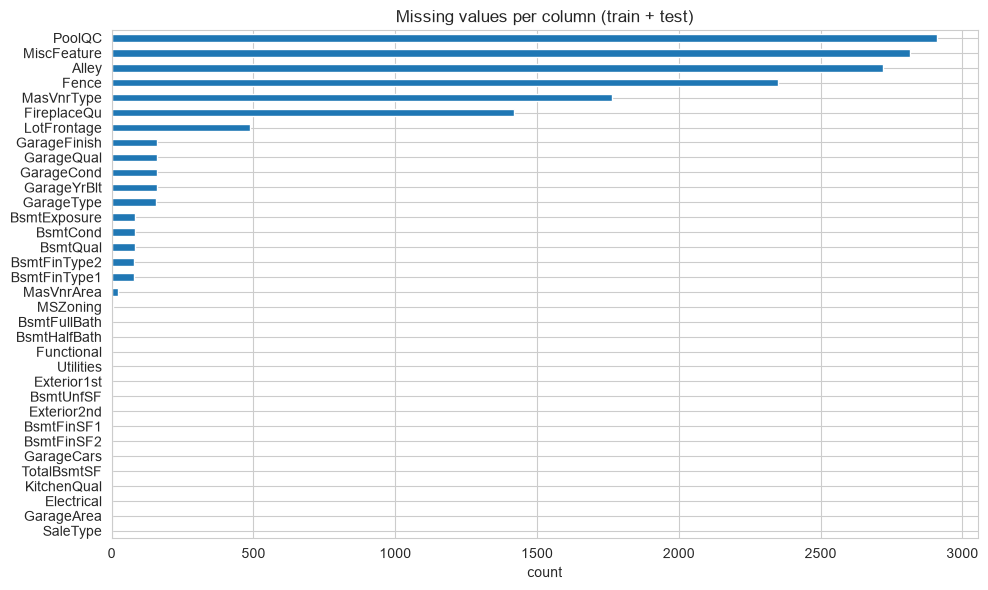

In [ ]:
plt.figure(figsize=(10, 6))
missing.sort_values().plot(kind="barh")
plt.title("Missing values per column (train + test)")
plt.xlabel("count")
plt.tight_layout()
plt.show()

### 1.4 What drives price? (correlations)
Top numeric drivers: overall quality, living area, garage size, basement/1st-floor area.

Top 10 positive correlations with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101


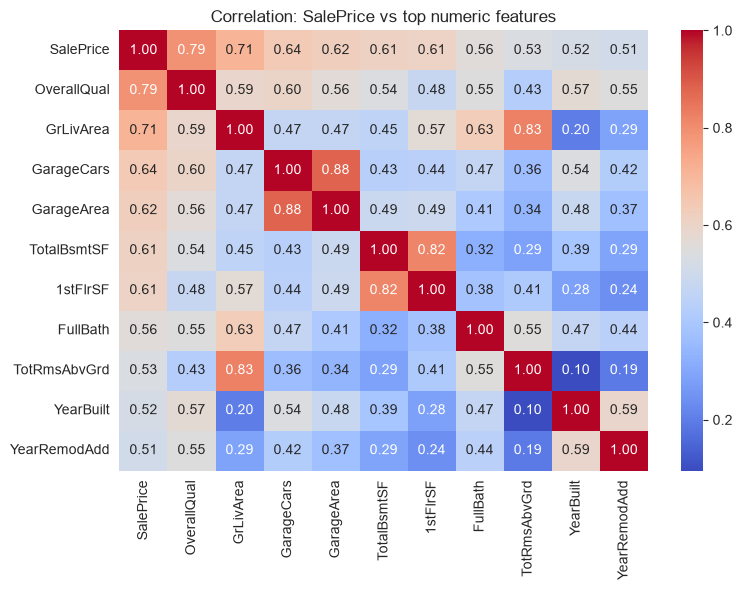

In [ ]:
corr = train[num_cols.tolist() + ["SalePrice"]].corr()["SalePrice"].drop("SalePrice")
corr = corr.sort_values(ascending=False)
print("Top 10 positive correlations with SalePrice:")
print(corr.head(10).to_string())

top = corr.head(10).index.tolist()
plt.figure(figsize=(8, 6))
sns.heatmap(train[["SalePrice"] + top].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation: SalePrice vs top numeric features")
plt.tight_layout()
plt.show()

### 1.5 Outliers
The competition author notes a few very large houses (`GrLivArea` > 4000) that sold cheap — these hurt linear models. We'll drop them in Phase 2.

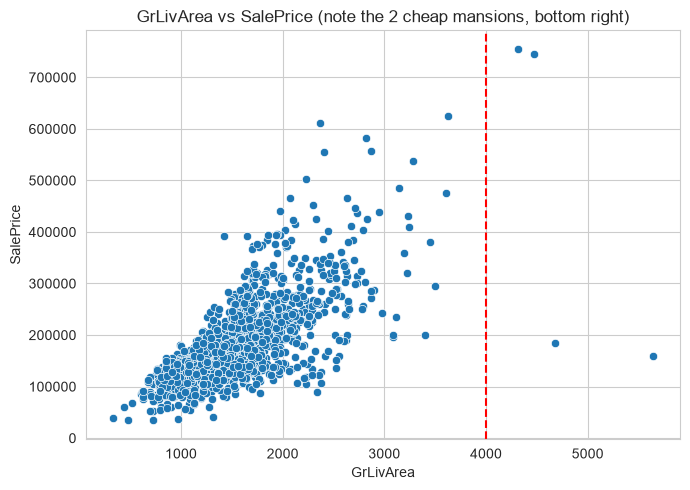

Candidate outliers (GrLivArea>4000 & SalePrice<300k):
  Id  GrLivArea  SalePrice
 524       4676     184750
1299       5642     160000


In [ ]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=train["GrLivArea"], y=train["SalePrice"])
plt.axvline(4000, color="red", ls="--")
plt.title("GrLivArea vs SalePrice (note the 2 cheap mansions, bottom right)")
plt.tight_layout()
plt.show()

outliers = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)]
print("Candidate outliers (GrLivArea>4000 & SalePrice<300k):")
print(outliers[["Id", "GrLivArea", "SalePrice"]].to_string(index=False))

## Phase 2 — Clean & handle missing values

Turn the raw, hole-y data into a complete, clean table — **no missing values, no junk rows** — while keeping it readable (categories stay as words). Encoding & new features come in Phase 3.

Steps:
1. Drop the 2 outlier rows from **train only**
2. Combine train + test so the same fill rules apply to both
3. Fix disguised numeric-as-categorical columns
4. Fill "feature absent" blanks with `None` / `0`
5. Estimate the genuinely-missing values (LotFrontage, mode fills)
6. Verify zero missing remain

### 2.1 Drop outliers (train only)

In [ ]:
before = len(train)
train = train[~((train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000))].reset_index(drop=True)
print(f"dropped {before - len(train)} outlier rows -> train now {train.shape}")

dropped 2 outlier rows -> train now (1458, 81)


### 2.2 Combine train + test
We stack both into one frame `both` for consistent cleaning, remember where train ends (`ntrain`), keep the target and test Ids aside. The target stays raw here — we log-transform it in Phase 3.

In [ ]:
ntrain = len(train)
y = train["SalePrice"].copy()        # raw target; log-transform in Phase 3
test_ids = test["Id"].copy()         # needed for the submission file

both = pd.concat([train.drop(columns="SalePrice"), test], ignore_index=True)
both = both.drop(columns="Id")       # Id is an identifier, not a feature
print("combined `both`:", both.shape)

combined `both`: (2917, 79)


### 2.3 Fix disguised data types
Some numbers are really category codes, not quantities — treat them as text so models don't read them as magnitudes.

In [ ]:
# MSSubClass = building-class code; MoSold = month (cyclical label, not a quantity)
for c in ["MSSubClass", "MoSold"]:
    both[c] = both[c].astype(str)

### 2.4 Fill "feature absent" blanks
Per `data_description.txt`, a blank in these columns means the house has **no** such feature — fill categoricals with `"None"` and their numeric partners with `0`.

In [ ]:
none_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
]
for c in none_cols:
    both[c] = both[c].fillna("None")

zero_cols = [
    "GarageYrBlt", "GarageArea", "GarageCars",
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath", "MasVnrArea",
]
for c in zero_cols:
    both[c] = both[c].fillna(0)

### 2.5 Estimate the genuinely-missing values
- `LotFrontage`: lots in the same neighborhood are similar widths → fill with the **neighborhood median**.
- `Functional`: data dictionary says blank means typical → `"Typ"`.
- A few columns have only 1–4 blanks → fill with the **most common value (mode)**.

In [ ]:
both["LotFrontage"] = both.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

both["Functional"] = both["Functional"].fillna("Typ")

mode_cols = ["MSZoning", "Electrical", "KitchenQual",
             "Exterior1st", "Exterior2nd", "SaleType", "Utilities"]
for c in mode_cols:
    both[c] = both[c].fillna(both[c].mode()[0])

### 2.6 Verify: zero missing values

In [ ]:
remaining = both.isnull().sum()
remaining = remaining[remaining > 0]
if len(remaining) == 0:
    print(f"All clean — 0 missing values across {both.shape[0]} rows x {both.shape[1]} cols.")
else:
    print("Still missing:")
    print(remaining.to_string())

All clean — 0 missing values across 2917 rows x 79 cols.


## Phase 3 — Feature engineering

Reshape the clean data into an **all-numeric table** that exposes the patterns a model can learn from. After this phase `both` has no text columns and we have final `X_train` / `X_test` / `y`.

Steps:
1. Log-transform the target
2. Add derived features (total SF, baths, ages, has-feature flags)
3. Ordinal-encode the ranked categories
4. Un-skew numeric features
5. One-hot encode the remaining categoricals
6. Split back into `X_train` / `X_test` and verify

### 3.1 Log-transform the target
Replace `y` with `log1p(y)` — matches the competition metric and makes the target ~normal. Note `y` is only valid after Phase 2's outlier drop has run (so it lines up with `X_train`).

In [ ]:
# Log-transform the target: matches the metric (RMSE of log price) and makes it ~normal.
# Undo with expm1 in Phase 6.
y = np.log1p(y)
print("target skew now:", round(y.skew(), 3))

### 3.2 Derived features
Combine raw columns into stronger signals: total square footage, total bathrooms, ages at sale, and simple has-feature flags.

In [ ]:
# Total square footage across basement + both floors
both["TotalSF"] = both["TotalBsmtSF"] + both["1stFlrSF"] + both["2ndFlrSF"]

# Bathrooms (half-baths count as 0.5), basement + above grade
both["TotalBath"] = (both["FullBath"] + 0.5 * both["HalfBath"]
                     + both["BsmtFullBath"] + 0.5 * both["BsmtHalfBath"])

# Ages at time of sale (clip negatives from remodel-after-sale quirks)
both["HouseAge"] = (both["YrSold"] - both["YearBuilt"]).clip(lower=0)
both["SinceRemodel"] = (both["YrSold"] - both["YearRemodAdd"]).clip(lower=0)

# Simple has-feature flags
both["HasPool"] = (both["PoolArea"] > 0).astype(int)
both["HasGarage"] = (both["GarageArea"] > 0).astype(int)
both["Has2ndFloor"] = (both["2ndFlrSF"] > 0).astype(int)
both["HasBsmt"] = (both["TotalBsmtSF"] > 0).astype(int)
both["HasFireplace"] = (both["Fireplaces"] > 0).astype(int)
print("added derived features; both now", both.shape)

### 3.3 Ordinal-encode the ranked categories
Columns whose categories have a natural order — quality grades `Po < Fa < TA < Gd < Ex`, basement finish, garage finish, etc. — become ordered integers so the model keeps that ranking. (The unordered ones are left for one-hot in 3.5.)

In [ ]:
# Quality/condition grades share one ranked scale
qual_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
qual_cols = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
             "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]
for c in qual_cols:
    both[c] = both[c].map(qual_map)

# Other columns with their own natural ordering
both["BsmtExposure"] = both["BsmtExposure"].map({"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4})
fin_map = {"None": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6}
for c in ["BsmtFinType1", "BsmtFinType2"]:
    both[c] = both[c].map(fin_map)
both["GarageFinish"] = both["GarageFinish"].map({"None": 0, "Unf": 1, "RFn": 2, "Fin": 3})
both["Functional"] = both["Functional"].map(
    {"Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4, "Mod": 5, "Min2": 6, "Min1": 7, "Typ": 8})

# sanity: mapping must not introduce NaNs (would mean an unexpected category)
ord_cols = qual_cols + ["BsmtExposure", "BsmtFinType1", "BsmtFinType2", "GarageFinish", "Functional"]
assert both[ord_cols].isnull().sum().sum() == 0, "unexpected category in an ordinal column"
print("ordinal encoding OK")

### 3.4 Un-skew numeric features
Apply `log1p` to numeric columns with strong right-skew (|skew| > 0.75), just like we did to the target. Only non-negative columns qualify (log1p needs ≥ 0).

In [ ]:
# Reduce right-skew in numeric features (same idea as the target) so large values don't dominate
numeric_feats = both.select_dtypes(include=[np.number]).columns
skewness = both[numeric_feats].apply(lambda x: x.skew()).abs()
skewed = [c for c in skewness[skewness > 0.75].index if both[c].min() >= 0]  # log1p needs >= 0
for c in skewed:
    both[c] = np.log1p(both[c])
print(f"log1p-transformed {len(skewed)} skewed numeric columns")

### 3.5 One-hot encode the rest
Unordered categoricals (e.g. `Neighborhood`, `RoofStyle`) become 0/1 dummy columns. After this the table is fully numeric.

In [ ]:
# One-hot encode the remaining unordered categoricals (Neighborhood, RoofStyle, ...)
n_obj = both.select_dtypes(include=["object"]).shape[1]
both = pd.get_dummies(both).astype(float)
print(f"one-hot encoded {n_obj} categorical columns -> total features: {both.shape[1]}")

### 3.6 Split back & verify
Slice `both` back into `X_train` / `X_test` using `ntrain`, then assert everything is numeric, complete, and column-aligned.

In [ ]:
# Split the engineered frame back into train / test matrices
X_train = both.iloc[:ntrain].copy()
X_test = both.iloc[ntrain:].copy()

assert list(X_train.columns) == list(X_test.columns), "train/test columns misaligned"
assert both.isnull().sum().sum() == 0, "missing values present"
assert both.select_dtypes(exclude=[np.number]).shape[1] == 0, "non-numeric columns remain"

print("X_train:", X_train.shape, "| X_test:", X_test.shape, "| y:", y.shape)
print("All numeric, no missing, columns aligned — ready for modeling.")

## Phase 4 — Modeling

Train several regression models, score each fairly with cross-validation (RMSE in log space — same as the metric), and combine the best into one blended predictor. We never touch the test answers; CV on `X_train` is how we judge quality.

Steps:
1. A reusable `rmse_cv()` scoring helper (5-fold)
2. Define the models (linear + gradient-boosted trees)
3. Score them all and compare
4. Blend the strongest, verified out-of-fold
5. Refit the blend members on all data for Phase 6

_Reference: a good score on this competition is ~0.11–0.12._

### 4.1 Scoring helper
One function used to score every model the same way: 5-fold cross-validation, returning RMSE. Lower is better.

In [ ]:
# 5-fold CV RMSE in log space. y is already logged, so this equals the competition metric.
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

def rmse_cv(model):
    neg_mse = cross_val_score(model, X_train, y, scoring="neg_mean_squared_error", cv=kf)
    return np.sqrt(-neg_mse)

### 4.2 Define the models
Two complementary families: **regularized linear** models (Ridge, Lasso, ElasticNet — strong here because we log/un-skewed everything) and **gradient-boosted trees** (GBoost, plus XGBoost/LightGBM if available — capture non-linear interactions).

In [ ]:
# Linear models get RobustScaler (resistant to remaining outliers); trees don't need scaling.
# Hyperparameters below were lightly tuned via CV on this dataset.
models = {
    "Ridge":      make_pipeline(RobustScaler(), Ridge(alpha=10)),
    "Lasso":      make_pipeline(RobustScaler(), Lasso(alpha=0.0005, max_iter=20000)),
    "ElasticNet": make_pipeline(RobustScaler(), ElasticNet(alpha=0.0005, l1_ratio=0.9, max_iter=20000)),
    "GBoost":     GradientBoostingRegressor(n_estimators=1000, learning_rate=0.05,
                                            max_depth=3, random_state=SEED),
}
if HAS_XGB:
    models["XGB"] = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=3,
                                 subsample=0.8, colsample_bytree=0.8,
                                 random_state=SEED, verbosity=0)
if HAS_LGBM:
    models["LGBM"] = LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=10,
                                   subsample=0.8, colsample_bytree=0.8,
                                   random_state=SEED, verbose=-1)
print(f"{len(models)} models defined:", ", ".join(models))

### 4.3 Score every model
Run each through 5-fold CV and compare. This cell trains 1000-tree boosters several times, so it takes a minute or two.

In [ ]:
scores = {}
for name, model in models.items():
    s = rmse_cv(model)
    scores[name] = s.mean()
    print(f"{name:11s} RMSE {s.mean():.4f} +/- {s.std():.4f}")

print("\nranked (lower is better):")
pd.Series(scores).sort_values()

### 4.4 Blend the best models
Average the predictions of the strongest, most *diverse* models (3 linear + 1 tree). We verify the blend with **out-of-fold** predictions — an honest estimate where each row is predicted only by models that never saw it. (Validated locally at ~0.110, beating every single model.)

In [ ]:
# Blend the strongest, most diverse models: 3 linear + 1 tree.
# Linear and tree models make different errors, so averaging them beats any single one.
BLEND_MEMBERS = ["Ridge", "Lasso", "ElasticNet"] + (["XGB"] if HAS_XGB else ["GBoost"])
print("blend members:", BLEND_MEMBERS)

# Honest check: out-of-fold predictions (each row predicted by a model that never saw it)
oof = {name: np.zeros(len(X_train)) for name in BLEND_MEMBERS}
for tr_idx, va_idx in kf.split(X_train):
    for name in BLEND_MEMBERS:
        models[name].fit(X_train.iloc[tr_idx], y.iloc[tr_idx])
        oof[name][va_idx] = models[name].predict(X_train.iloc[va_idx])

blend_oof = np.mean([oof[name] for name in BLEND_MEMBERS], axis=0)
blend_rmse = np.sqrt(mean_squared_error(y, blend_oof))
print(f"equal-weight blend out-of-fold RMSE: {blend_rmse:.4f}")

### 4.5 Refit on all data
Cross-validation was for *judging*. Now refit each blend member on the full `X_train` so they've seen every row before predicting the real test set in Phase 6.

In [ ]:
# Refit each blend member on ALL training data — these are used for the final Phase 6 prediction
final_models = {}
for name in BLEND_MEMBERS:
    models[name].fit(X_train, y)
    final_models[name] = models[name]
print("final models fitted on full training data:", list(final_models))

## Phase 5 — Validation

Confirm the ~0.11 blend score is **real and stable**, and check for systematic errors — before spending a submission. Diagnostics only; nothing here changes the model.

Steps:
1. Score summary (all models + blend)
2. Fold stability
3. Residual analysis
4. Biggest misses & dollar sanity-check

_Depends on `scores`, `oof`, `blend_oof`, `blend_rmse`, `kf` from Phase 4 — run Phase 4 first._

### 5.1 Score summary
All model CV scores plus the blend in one ranking, so the best choice is unambiguous.

In [ ]:
# Combine individual CV scores with the blend for one clear ranking
summary = pd.Series(scores).to_frame("cv_rmse")
summary.loc["BLEND"] = blend_rmse
summary = summary.sort_values("cv_rmse")
print("Cross-validated RMSE in log space (lower is better):")
summary.round(4)

### 5.2 Fold stability
The blend's RMSE on each of the 5 folds. A tight spread means the score is trustworthy, not the result of one lucky split.

In [ ]:
# Is the blend score stable, or driven by one lucky fold?
fold_rmse = [np.sqrt(mean_squared_error(y.iloc[va], blend_oof[va])) for _, va in kf.split(X_train)]
for i, r in enumerate(fold_rmse, 1):
    print(f"fold {i}: {r:.4f}")
print(f"\nblend mean {np.mean(fold_rmse):.4f} +/- {np.std(fold_rmse):.4f}  (tight spread = trustworthy)")

### 5.3 Residual analysis
Using out-of-fold predictions: points should hug the diagonal, and residuals should be a flat random cloud centered on zero — no systematic over/under-prediction.

In [ ]:
# Diagnostics from out-of-fold predictions (honest: each row predicted by models that never saw it)
resid = y.values - blend_oof

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
lims = [y.min(), y.max()]
ax[0].scatter(blend_oof, y.values, alpha=0.4, s=15)
ax[0].plot(lims, lims, "r--")
ax[0].set(xlabel="predicted (log)", ylabel="actual (log)", title="Predicted vs Actual")
ax[1].scatter(blend_oof, resid, alpha=0.4, s=15)
ax[1].axhline(0, color="r", ls="--")
ax[1].set(xlabel="predicted (log)", ylabel="residual", title="Residuals (want a flat, random cloud)")
plt.tight_layout(); plt.show()

print(f"residual mean {resid.mean():.5f} (≈0 = unbiased), std {resid.std():.4f}")

### 5.4 Biggest misses & dollar sanity-check
List the houses we got most wrong, and confirm predictions convert back to believable dollar amounts (no negatives, sensible range) before Phase 6 does it for real.

In [ ]:
# Where do we miss most, and do predictions convert back to sensible dollars?
diag = pd.DataFrame({"actual": np.expm1(y.values), "predicted": np.expm1(blend_oof)})
diag["abs_err"] = (diag["actual"] - diag["predicted"]).abs()
print("10 biggest out-of-fold misses (dollars):")
print(diag.sort_values("abs_err", ascending=False).head(10).round(0).to_string())

print(f"\nprediction range: ${diag.predicted.min():,.0f} to ${diag.predicted.max():,.0f}")
print(f"actual range:     ${diag.actual.min():,.0f} to ${diag.actual.max():,.0f}")
print("any negative predictions:", bool((diag.predicted < 0).any()))

## Phase 6 — Predict & submit

Apply the trained blend to the real test set, convert log predictions back to dollars, and write the Kaggle submission file.

Steps:
1. Predict `X_test` with the blend (`final_models`) and `expm1` back to dollars
2. Build & sanity-check the `Id,SalePrice` table
3. Write `submission.csv`

_Depends on `final_models`, `BLEND_MEMBERS`, `X_test`, `test_ids`, `sample_submission` — run Phases 0–4 first._

### 6.1 Predict the test set
Average the blend members' predictions (refit on all data in Phase 4), then `expm1` to undo the log transform and get dollars.

In [ ]:
# Average the blend members' predictions on the test set (log space), then convert to dollars
test_preds_log = np.mean([final_models[name].predict(X_test) for name in BLEND_MEMBERS], axis=0)
test_preds = np.expm1(test_preds_log)
print(f"predicted {len(test_preds)} test prices")
print(f"range: ${test_preds.min():,.0f} to ${test_preds.max():,.0f}, median ${np.median(test_preds):,.0f}")

### 6.2 Build & sanity-check the submission
Assemble `Id,SalePrice`, then assert row count, Id order, positivity, and no-NaNs match what Kaggle expects.

In [ ]:
submission = pd.DataFrame({"Id": test_ids, "SalePrice": test_preds})

# Sanity checks before writing
assert submission.shape[0] == len(sample_submission), "wrong number of rows"
assert submission["Id"].equals(sample_submission["Id"]), "Ids don't match expected order"
assert (submission["SalePrice"] > 0).all(), "non-positive price"
assert not submission["SalePrice"].isna().any(), "NaN in predictions"
print("all checks passed")
submission.head()

### 6.3 Write submission.csv
Writes to the current directory — scored automatically on Kaggle, saved to the project folder locally.

In [ ]:
# On Kaggle, a submission.csv in the working dir is what gets scored;
# locally it lands in the project folder. Upload this file to the competition.
submission.to_csv("submission.csv", index=False)
print("wrote submission.csv", submission.shape)